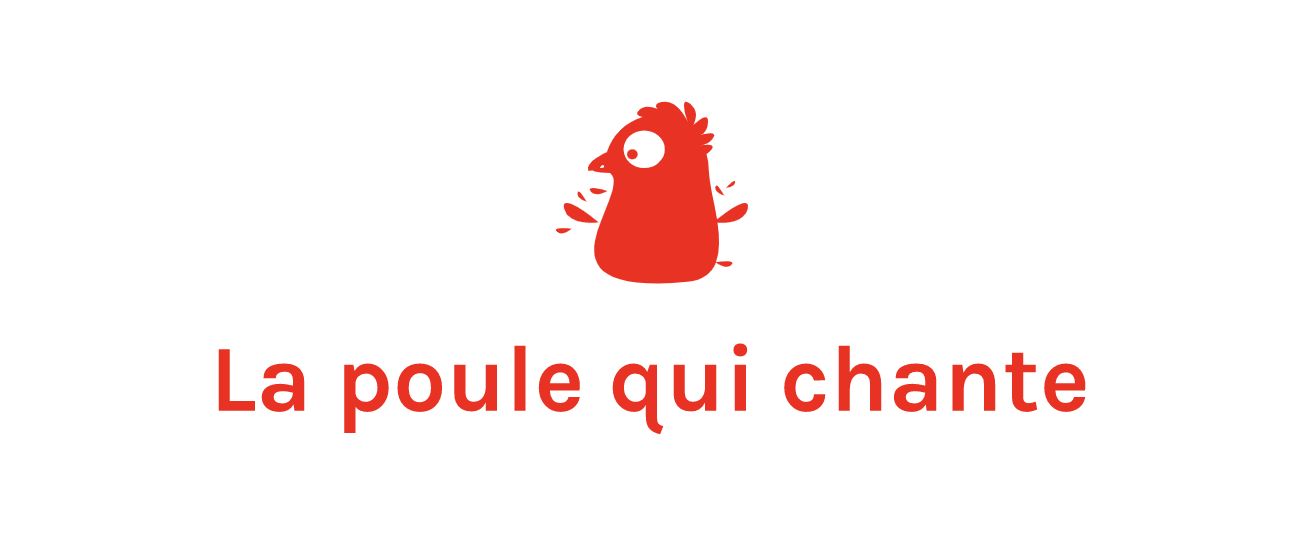

In [463]:
from IPython.display import Image, display

# Afficher l'image
display(Image(filename='C:/Users/Willkommen/OneDrive/Docs privés/HERVE/FORMATION/DATA_ANALYST_OC/PROJET 11/logo-la-poule-qui-chante.png'))


# Produire une étude de marché avec Python
## Partie 2 : Clustering

> &#9888; Ce *notebook* est le second des deux *notebooks* qui vont composer notre étude de marché. Il contient l'analyse des groupements de pays en utilisant la classification ascendante  
hiérarchique puis la méthode des *k-means*. Il contient également une ACP afin de visualier les résultats de l'analyse.  

Nous travaillons chez La poule qui chante, une entreprise française d’agroalimentaire. Son activité principale est l’élevage et la vente de poulets sous le label “Poulet Agriculture Biologique”.  
Son activité actuelle est franco-française mais Patrick, le PDG de l’entreprise souhaite évaluer la possibilité de se développer à l'international. Pour l'instant, le champ des possibles est bien  
large : aucun pays particulier ni aucun continent n'est pour le moment choisi. Tous les pays sont envisageables !  

Notre objectif sera de proposer une analyse des groupements de pays que l’on peut cibler pour exporter nos poulets. Nous approfondirons ensuite l'étude de marché.  
L’idéal serait d’avoir au minimum 100 pays dans notre analyse (qui couvrent au moins 60% de la population mondiale).  

Les données qui vont être utilisées seront toutes issues des [statistiques de la *Food and Agriculture Organization of the United Nations (FAO)*](https://www.fao.org/faostat/fr/#home).
Nous disposons déjà de deux de leurs jeux de données.  
Nous avons récupéré d'autres données dont nous allons avoir besoin afin d'élargir les critères de l'analyse issues des [statistiques de la *Banque Mondiale*](https://donnees.banquemondiale.org/indicateur).  

Tous ces critères, que nous appellerons **indicateurs** dans la suite de cette étude, ont été choisis en nous inspirant de l'analyse PESTEL et avec pour objectif de pouvoir caractériser les pays.  
En voici la synthèse.

|Nom de variable               |Indicateur<sup>[1]</sup>                             |Information                                      |
|------------------------------|-----------------------------------------------------|-------------------------------------------------|
|`population_milliers_hab`     |Population en milliers d'habitants                   |Potentiel du marché                              |
|`consommation_volaille_pct`   |Ratio de consommation de volaille dans l'alimentation|Appétence des consommateurs pour la volaille     |
|`tdi_pct`                     |Taux de dépendance aux importations pour la volaille |Nécessité des pays à importer                    |
|`disponibilite_kg_p_an`       |Disponibilité de volaille par personne               |Volume de volaille alimentaire                   |
|`taux_de_croissance_pct`      |Taux de croissance du PIB                            |Dynamique économique du pays                     |
|`revenu_par_habitant_usd`     |Revenu par habitant en US$                           |Pouvoir d'achat des consommateurs                |
|`indice_stabilite_politique`  |Indice de stabilité politique                        |Facilité et risques liés aux échanges commerciaux|
|`indice_logistique`           |Indice de performance logistique                     |Qualité des infrastructures essentielles         |

*1. Les indicateurs sont donnés pour l'année 2022.*

In [464]:
# Importe les librairies
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

## Importation et préparation des données<a id='1'></a>

Nous importons dans un *DataFrame* les indicateurs des différents pays à partir du *dataset* préparé précédemment.

In [465]:
# Importation du fichier csv
df_indicateurs = pd.read_csv('C:/Users/Willkommen/OneDrive/Docs privés/HERVE/FORMATION/DATA_ANALYST_OC/PROJET 11/DATA/indicateurs-pays-2022.csv', sep=",", encoding='utf-8')

In [466]:
df_indicateurs.head(15)

,pays,indice_logistique,population_milliers_hab,consommation_volaille_pct,tdi_pct,disponibilite_kg_p_an,taux_croissance_pct,revenu_par_habitant_usd,indice_stabilite_politique
0,Afghanistan,1.700000,40578.842,0.22,19.44,0.87,-6.503076,348.593157,-2.55
1,Angola,2.100000,35635.029,1.56,84.27,10.52,62.082101,3007.154873,-0.65
2,Albanie,2.700000,2827.608,1.74,72.31,22.56,5.497950,6562.106096,0.11
3,Émirats arabes unis,4.100000,10242.086,7.07,114.34,55.25,22.131471,53713.748333,0.70
4,Argentine,2.800000,45407.904,5.77,0.64,48.19,29.356387,13569.725185,-0.01
5,Arménie,2.600000,2880.874,1.78,76.92,18.45,40.599190,6909.162900,-0.80
6,Antigua-et-Barbuda,2.700000,92.840,7.78,100.00,68.33,13.439739,18247.346730,0.94
7,Australie,4.100000,26200.984,4.48,0.30,49.09,1.362986,65058.904861,0.93
8,Autriche,3.900000,9064.677,1.78,63.35,19.14,-1.876337,52574.629814,0.64
9,Azerbaïdjan,2.714286,10295.304,1.75,22.75,16.06,43.584984,7551.885849,-0.93


In [467]:
df_indicateurs.shape

(158, 9)

Nous savons que notre df_indicateurs contient 159 pays avec 8 variables d'analyse. Pour répondre à la question qui nous a été posée  
nous devons réduire le nombre de variables nécessaires à la représentation de nos données, tout en perdant le moins d'information possible.  
C'est la première étape de notre analyse multidimensionnelle, aussi appelée méthode factorielle ou Analyse en Composantes Principales (ACP).  
Dans la seconde étape, nous essayerons de regrouper les individus (pays) similaires. Cette étape se nomme le clustering ou méthode de classification  
non supervisée ou partitionnement de données.

## Analyse en Composantes Principales

L'ACP permet d'étudier :  
- la variabilité entre les individus, c'est-à-dire les différences et les ressemblances entre les individus  
- les liaisons entre les variables : y a-t-il des groupes de variables très corrélées entre elles, qui peuvent être regroupées en de nouvelles variables synthétiques  

Sachant que nos variables de chaque individu (pays) sont toutes différentes, la première étape de notre ACP consiste à créer  
des dimensions synthétiques calculées à partir des dimensions initiales.  

On souhaite réduire le nombre de dimensions, mais en perdant le moins d'information possible.  

Ce travail consiste en fait à maximiser la variance de nos données, au travers de la création de nos nouvelles dimensions.  

Pour ce faire, il est important de ramener les données dans des échelles de grandeur similaires, où la moyenne de chaque dimension est à 0, et l'écart-type est de 1.  

On parle de centrer-réduire nos données.  

Pour la suite de cette étude et sachant que nous appliquerons différents algorithmes, nous devons stocker uniquement les valeurs numériques  
de nos variables.

In [468]:
# Supprime la colonne 'pays' et crée un df 'X'
X = df_indicateurs.drop('pays', axis='columns')
print(X.dtypes) # vérifie que toutes les données sont format numérique

indice_logistique             float64
population_milliers_hab       float64
consommation_volaille_pct     float64
tdi_pct                       float64
disponibilite_kg_p_an         float64
taux_croissance_pct           float64
revenu_par_habitant_usd       float64
indice_stabilite_politique    float64
dtype: object


In [469]:
pays = df_indicateurs['pays'].to_numpy() # Crée une liste de tous les pays

indicateurs = df_indicateurs.drop(columns='pays').columns.to_numpy() # Crée une liste de tous les indicateurs

features = df_indicateurs.drop(columns='pays').columns

### Centrer et réduire

In [470]:
X.describe()

,indice_logistique,population_milliers_hab,consommation_volaille_pct,tdi_pct,disponibilite_kg_p_an,taux_croissance_pct,revenu_par_habitant_usd,indice_stabilite_politique
count,158.000000,1.580000e+02,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,2.813491,4.717552e+04,2.638608,39.256835,21.527342,7.812758,15972.285870,-0.200063
std,0.686193,1.649077e+05,1.976749,39.718632,16.662221,13.890684,21804.190448,0.918244
min,1.700000,9.284000e+01,0.110000,0.000000,0.400000,-19.654569,314.298213,-2.800000
25%,2.300000,3.491881e+03,1.180000,4.647500,7.187500,-1.492034,2045.126381,-0.690000
50%,2.600000,1.047560e+04,2.085000,23.220000,19.205000,5.865381,6511.997328,-0.140000
75%,3.375000,3.302593e+04,3.745000,73.402500,30.505000,13.107699,20017.958363,0.530000
max,4.400000,1.425423e+06,8.300000,219.850000,70.830000,83.033524,109081.979894,1.310000


On peut ensuite "scaler" nos données

In [471]:
# Standardisation des données
# Normaliser les données
scaler = StandardScaler() # On instancie notre scaler
X_scaled = scaler.fit_transform(X) # On le fit, on l'entraine et on le stocke dans un nouveau df 'X_scaled'

Nous vérifions nos moyennes et nos écarts-types de notre nouveau df 'X_scaled'

In [472]:
idx = ["mean", "std"]

pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2,3,4,5,6,7
mean,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Maintenant que nos données sont standardisées, nous pouvons entrer dans le vif du sujet de notre ACP

In [473]:
n_components = 8

In [474]:
# Effectue la décomposition sur toutes les dimensions
pca = PCA(n_components=n_components) # On instancie notre ACP (PCA)
X_pca=pca.fit_transform(X_scaled) # On le fit, on l'entraine et on le stocke dans un nouveau df 'X_pca'

Nous allons nous intéresser à la variance captée de nos composantes (variables). Pour ce faire, nous pouvons utiliser  
`pca.explained_variance_` et `pca.explained_variance_ratio_`

In [475]:
# Nombre réel de composantes
n_composantes = len(pca.explained_variance_)

# Création du DataFrame des valeurs propres
comp = pd.DataFrame(
    {
        "Dimension" : ["Dim" + str(x + 1) for x in range(n_composantes)], 
        "Valeur propre" : pca.explained_variance_,
        "% variance expliquée" : np.round(pca.explained_variance_ratio_ * 100, 2),
        "% cum. var. expliquée" : np.round(np.cumsum(pca.explained_variance_ratio_) * 100, 2)
    },
    columns=["Dimension", "Valeur propre", "% variance expliquée", "% cum. var. expliquée"]
)

# Affichage du tableau
print(comp)


  Dimension  Valeur propre  % variance expliquée  % cum. var. expliquée
0      Dim1       3.000691                 37.27                  37.27
1      Dim2       1.532080                 19.03                  56.30
2      Dim3       1.275110                 15.84                  72.14
3      Dim4       0.904147                 11.23                  83.37
4      Dim5       0.653270                  8.11                  91.48
5      Dim6       0.447708                  5.56                  97.04
6      Dim7       0.191149                  2.37                  99.42
7      Dim8       0.046800                  0.58                 100.00


Notre 1ère composante (Dim1) capte 37,27 % de la variance de nos données initiales, la 2ème 19,03 %, etc...  
Nous remarquons qu'à la 4ème composante, la variance captée cumulée de nos données initiales est de 83,37 %.

Nous pouvons afficher les valeurs propres de chaque composante sous la forme d'un graphique dit des éboulis.

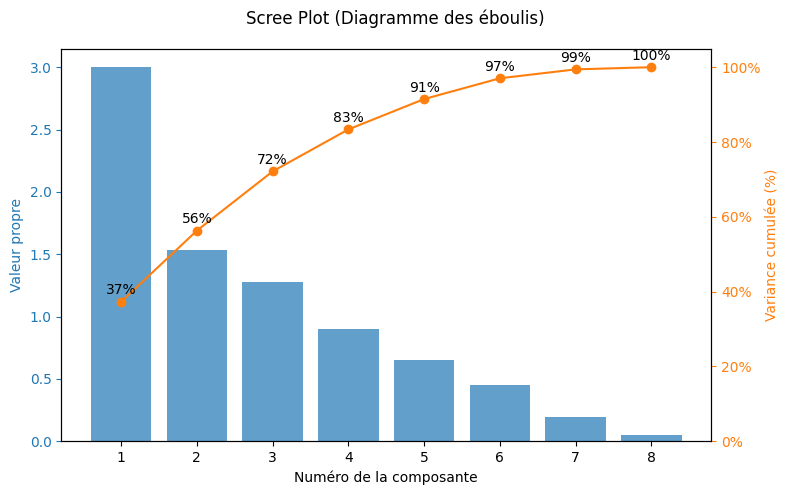

In [476]:
# Récupération des données depuis comp
n_composantes = len(comp)
explained_variance = comp["Valeur propre"].values
cumulative_variance = comp["% cum. var. expliquée"].values / 100  # Convertir en fraction

# Indices des composantes (commencent à 1)
indices = np.arange(1, n_composantes + 1)

# Création de la figure et des axes
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

# Graphe des valeurs propres (barres)
ax1.bar(indices, explained_variance, color='C0', alpha=0.7, label="Valeur propre")

# Graphe de la variance cumulée (courbe)
ax2.plot(indices, cumulative_variance, color='C1', marker='o', label="Variance cumulée")

# Ajout des valeurs de variance cumulée sur la courbe
for x, y in zip(indices, cumulative_variance):
    ax2.text(x, y + 0.02, f'{y:.0%}', ha='center', fontsize=10)

# Paramètres des axes
ax1.set_xlabel('Numéro de la composante')
ax1.set_ylabel('Valeur propre', color='C0')
ax2.set_ylabel('Variance cumulée (%)', color='C1')

ax1.tick_params(axis='y', colors='C0')
ax2.tick_params(axis='y', colors='C1')

# Format de l'axe secondaire en pourcentage
ax2.set_ylim(0, 1.05)  # Pourcentage entre 0 et 100%
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x*100)}%"))

# Titre et affichage
fig.suptitle('Scree Plot (Diagramme des éboulis)')
fig.tight_layout()
plt.show()

Le graphique nous indique en bleu les valeurs propres de chaque composante, la courbe orange nous indique le pourcentage  
cumulé de variance expliquée.  
Comme mentionné précédemment, nous remarquons qu'à la 4ème composante, la variance captée cumulée de nos données initiales est de 83 % et 91 % à la 5ème composante.

### Nos composantes

Nos composantes sont issues d'un calcul dont la formule nous est donnée par l'attribut `components_`.  
Cette variable est généralement nommée pcs

In [477]:
pcs = pca.components_
pcs

array([[ 0.45504212, -0.05941822,  0.40029283,  0.13821131,  0.46818007,
         0.0157361 ,  0.45672723,  0.4266491 ],
       [-0.29822555, -0.02823761,  0.51477195, -0.32230279,  0.43478322,
         0.45507345, -0.27628722, -0.26254902],
       [ 0.27815756,  0.69479963,  0.02648179, -0.57710492,  0.0226401 ,
        -0.26642146,  0.09829127, -0.15803902],
       [ 0.12104066,  0.50298504, -0.20542706,  0.33850859, -0.10128889,
         0.74032318,  0.12798542, -0.02913318],
       [-0.15980246,  0.45788635,  0.29259827,  0.58097057,  0.16229887,
        -0.37317649, -0.41626631,  0.05275847],
       [-0.18092898,  0.12062638, -0.08716658, -0.30306393, -0.08994375,
         0.14112678, -0.33675488,  0.84371662],
       [ 0.74268354, -0.18804502,  0.06762486, -0.00203436, -0.13632606,
         0.10938347, -0.60906275, -0.08352238],
       [ 0.04609508, -0.01897563, -0.65885434,  0.00130746,  0.72662463,
        -0.04959355, -0.17715878, -0.03995382]])

Nous pouvons également l'afficher en version pandas

In [478]:
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7
0,0.455042,-0.059418,0.400293,0.138211,0.468180,0.015736,0.456727,0.426649
1,-0.298226,-0.028238,0.514772,-0.322303,0.434783,0.455073,-0.276287,-0.262549
2,0.278158,0.694800,0.026482,-0.577105,0.022640,-0.266421,0.098291,-0.158039
3,0.121041,0.502985,-0.205427,0.338509,-0.101289,0.740323,0.127985,-0.029133
4,-0.159802,0.457886,0.292598,0.580971,0.162299,-0.373176,-0.416266,0.052758
5,-0.180929,0.120626,-0.087167,-0.303064,-0.089944,0.141127,-0.336755,0.843717
6,0.742684,-0.188045,0.067625,-0.002034,-0.136326,0.109383,-0.609063,-0.083522
7,0.046095,-0.018976,-0.658854,0.001307,0.726625,-0.049594,-0.177159,-0.039954


Avec le nom des indicateurs d'origine et arrondi à 2 décimales :

In [479]:
x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3, 4, 5, 6, 7, 8]

In [480]:
pcs.columns = features
pcs.index = [f"F{i}" for i in x_list]
pcs.round(2)

,indice_logistique,population_milliers_hab,consommation_volaille_pct,tdi_pct,disponibilite_kg_p_an,taux_croissance_pct,revenu_par_habitant_usd,indice_stabilite_politique
F1,0.46,-0.06,0.40,0.14,0.47,0.02,0.46,0.43
F2,-0.30,-0.03,0.51,-0.32,0.43,0.46,-0.28,-0.26
F3,0.28,0.69,0.03,-0.58,0.02,-0.27,0.10,-0.16
F4,0.12,0.50,-0.21,0.34,-0.10,0.74,0.13,-0.03
F5,-0.16,0.46,0.29,0.58,0.16,-0.37,-0.42,0.05
F6,-0.18,0.12,-0.09,-0.30,-0.09,0.14,-0.34,0.84
F7,0.74,-0.19,0.07,-0.00,-0.14,0.11,-0.61,-0.08
F8,0.05,-0.02,-0.66,0.00,0.73,-0.05,-0.18,-0.04


ou encore transposé de la sorte :

In [481]:
pcs.T

,F1,F2,F3,F4,F5,F6,F7,F8
indice_logistique,0.455042,-0.298226,0.278158,0.121041,-0.159802,-0.180929,0.742684,0.046095
population_milliers_hab,-0.059418,-0.028238,0.694800,0.502985,0.457886,0.120626,-0.188045,-0.018976
consommation_volaille_pct,0.400293,0.514772,0.026482,-0.205427,0.292598,-0.087167,0.067625,-0.658854
tdi_pct,0.138211,-0.322303,-0.577105,0.338509,0.580971,-0.303064,-0.002034,0.001307
disponibilite_kg_p_an,0.468180,0.434783,0.022640,-0.101289,0.162299,-0.089944,-0.136326,0.726625
taux_croissance_pct,0.015736,0.455073,-0.266421,0.740323,-0.373176,0.141127,0.109383,-0.049594
revenu_par_habitant_usd,0.456727,-0.276287,0.098291,0.127985,-0.416266,-0.336755,-0.609063,-0.177159
indice_stabilite_politique,0.426649,-0.262549,-0.158039,-0.029133,0.052758,0.843717,-0.083522,-0.039954


Pour une représentation encore plus visuelle, nous pouvons l'afficher dans une heatmap.

<Axes: >

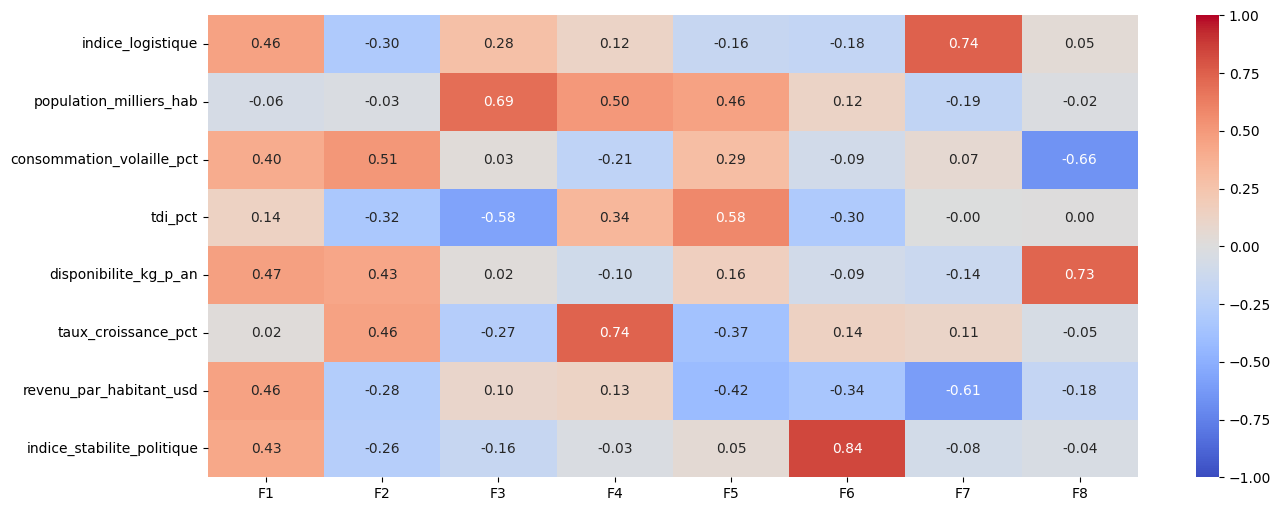

In [482]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

#### Représentation du graphique
-  Les colonnes représentent les facteurs principaux (F1, F2, ...) obtenus après l'ACP.  
-  Les lignes correspondent aux variables initiales (indice_logistique, population_milliers_hab, etc.).  
-  Les valeurs dans la heatmap indiquent les corrélations (ou cosinus carrés) entre les variables et les facteurs principaux.  
    - Rouge foncé → forte corrélation positive.  
    - Bleu foncé → forte corrélation négative.  
    - Couleurs claires → faible corrélation (proche de 0).

#### Interprétation des résultats  
1) Facteur 1 (F1) :  
Les variables ayant les corrélations les plus fortes avec F1 sont :
- indice_logistique (0.46),
- disponibilite_kg_p_an (0.47),
- revenu_par_habitant_usd (0.46),
- indice_stabilite_politique (0.43).  

Interprétation : F1 semble capturer une dimension liée aux infrastructures économiques et politiques (logistique, revenu, stabilité).  

2) Facteur 2 (F2) :

Variables importantes :
- consommation_volaille_pct (0.51),
- taux_croissance_pct (0.46),
- disponibilite_kg_p_an (0.43).  

Interprétation : F2 est peut-être lié à la croissance économique et à la consommation alimentaire.

3) Facteur 3 (F3) :

Variable dominante :
- population_milliers_hab (0.69).  

Interprétation : F3 semble refléter l'importance démographique.  

4) Facteur 4 (F4) :

Variable dominante :
- taux_croissance_pct (0.74).  

Interprétation : F4 capture spécifiquement une dimension économique.

### Les cercles de corrélation

Nous étudions ensuite les liaisons entre nos variables d'origine et les composantes principales en nous aidant du cercle des corrélations grâce à une fonction qui va nous permettre de tracer ce cercle en fonction des composantes principales que l'on souhaite afficher.

In [483]:
def correlation_graph(pca, 
                      x_y, 
                      features) : 
    """Affiche le graphe des correlations

    Positional arguments : 
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y 
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 8))

    # Pour chaque composante : 
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0, 
                pca.components_[x, i],  
                pca.components_[y, i],  
                head_width=0.07,
                head_length=0.07, 
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])
        
    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle 
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

Nous définissons nos axes x et y. Nous allons utiliser les 2 premières composantes F1 et F2. 

In [484]:
x_y = (0,1)
x_y

(0, 1)

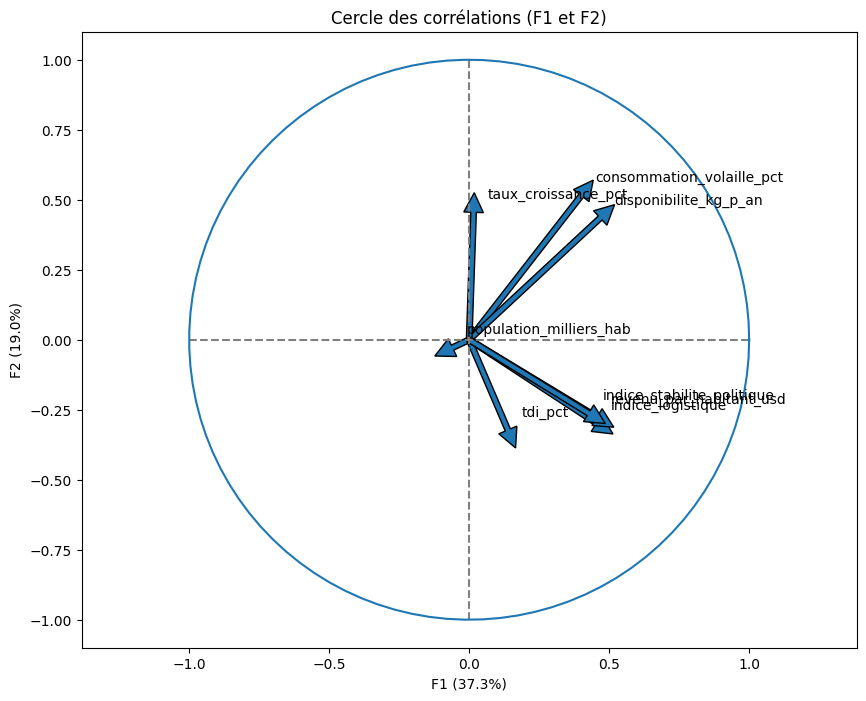

In [485]:
correlation_graph(pca, x_y, features)

Nos interprétations de nos composantes F1 et F2 faites sur la base de la heatmap se confirment.  
Pour F1, les variables les plus corrélées sont : disponibilité_kg_p_an, indice_stabilite_politique, revenu_par_habitant_usd et indice_logistique  
Pour F2, ce sont : consommation_volaille_pct, taux_croissance_pct et disponibilité_kg_p_an

Nous affichons le cercle des corrélations pour F3 et F4

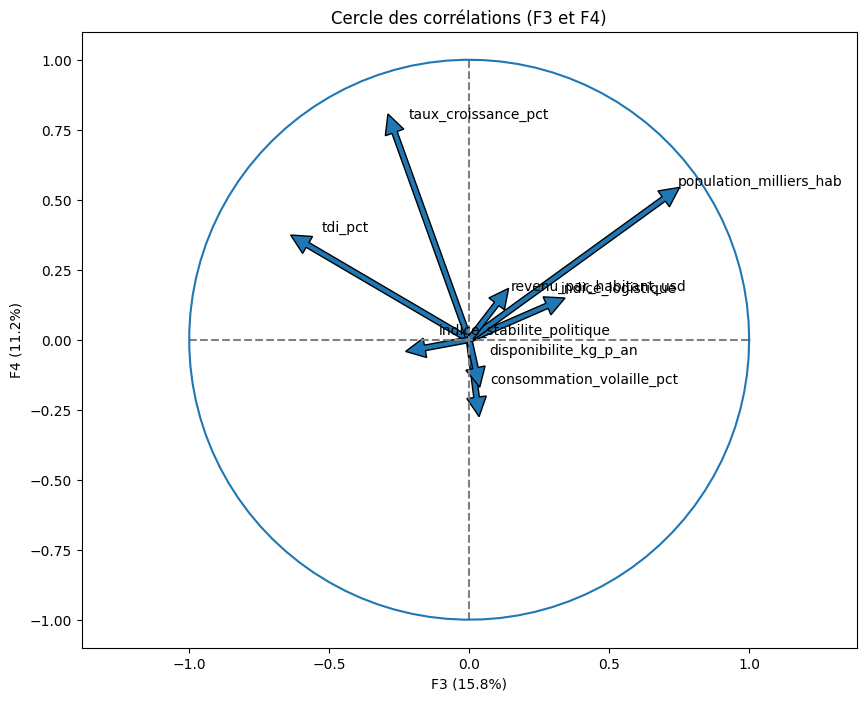

In [486]:
correlation_graph(pca, (2,3), features)

Pour F3, c'est la variable population_milliers_hab la plus corrélée et  
pour F4, c'est la variable taux_croissance_pct

### Projection

Avant de projeter nos individus (pays), nous devons sélectionner différents facteurs pour cette projection.  

Pour sélectionner les deux facteurs principaux à utiliser pour nos projections, nous allons nous baser sur les critères suivants :  
- Part de variance expliquée : Les facteurs doivent expliquer une part significative de la variance des données.
- Interprétation : Les facteurs doivent être pertinents et distincts dans leur signification pour l'analyse des données.
- Contributions des variables : Les facteurs doivent refléter la diversité des dimensions présentes dans nos données.  

#### Part de variance expliquée :
- Facteur 1 (F1) : Explique une grande partie de la variance totale (37.27 %).
- Facteur 2 (F2) : Explique une autre part importante (19.03 %).
- Facteur 3 (F3) : Explique moins de variance (15.84 %)
- Facteur 4 (F4) : Plus spécifique, explique encore moins de variance (11.23 %).  

#### Corrélations et interprétations des facteurs :
F1 : Il est corrélé fortement avec des variables comme indice_logistique, revenu_par_habitant_usd, disponibilite_kg_p_an, et indice_stabilite_politique.    
Il représente une dimension économique et politique globale.  
Intérêt : Permet de capturer des différences entre pays selon leur niveau de développement.  

F2 : Corrélé avec consommation_volaille_pct, taux_croissance_pct, et disponibilite_kg_p_an.  
Il représente une dimension de consommation et de croissance économique.  
Intérêt : Pertinent pour analyser les comportements alimentaires et la dynamique économique.  

F3 : Corrélé uniquement avec population_milliers_hab.  
Il capture une dimension démographique.  
Intérêt : Pertinent si les différences de taille démographique entre les pays sont cruciales dans l’analyse.  

F4 : Corrélé fortement avec taux_croissance_pct.  
Il représente une dimension économique isolée.  
Intérêt : Pertinent si le taux de croissance est une variable clé.  

Nous recommandons :  
### F1 et F2  

#### Justifications :  
1) Part de variance expliquée :  

    F1 et F2 expliquent ensemble une part importante de la variance (~50%).  
    Ils permettent de réduire la dimensionnalité tout en conservant l'essentiel de l'information des données.  

2) Pertinence des dimensions :

    F1 capture les différences économiques et politiques globales (des variables comme le revenu, la logistique, etc.).  
    F2 capture des comportements alimentaires et économiques spécifiques (consommation et croissance).  
    Leur combinaison permet une bonne séparation des pays sur des axes significatifs et complémentaires.  

3) Diversité des contributions :

    Les variables associées à F1 (logistique, revenu, etc.) et F2 (consommation, croissance) sont bien distinctes.  
    F1 et F2 apportent des informations non redondantes.

Pour projeter nos individus, nous définissons une fonction.

In [487]:
X_proj = pca.transform(X_scaled)
X_proj[:5]

array([[-3.32106203, -0.12251213,  0.35803194, -0.79114605, -0.06042056,
        -1.40968635, -0.57473294,  0.111241  ],
       [-1.26321636,  1.4541536 , -2.04966814,  3.24239011, -0.71289321,
         0.28228538,  0.12260775, -0.23522068],
       [-0.15337148, -0.46508569, -0.7775987 ,  0.02515956,  0.52513128,
         0.18663751,  0.1036073 ,  0.41565664],
       [ 4.21095461,  0.60731139, -0.88206701,  1.04810949,  0.62901372,
        -0.92993719,  0.2839198 , -0.31115349],
       [ 1.30713057,  2.52059968,  0.17015139,  0.30464038, -0.36655236,
         0.44695227,  0.09815217,  0.05155923]])

In [488]:
def display_factorial_planes(   X_projected, 
                                x_y, 
                                pca=None, 
                                labels = None,
                                clusters=None, 
                                alpha=1,
                                figsize=[10,8], 
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments : 
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments : 
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8] 
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize: 
        figsize = (7,6)

    # On gère les labels
    if  labels is None : 
        labels = []
    try : 
        len(labels)
    except Exception as e : 
        raise e

    # On vérifie la variable axis 
    if not len(x_y) ==2 : 
        raise AttributeError("2 axes sont demandées")   
    if max(x_y )>= X_.shape[1] : 
        raise AttributeError("la variable axis n'est pas bonne")   

    # on définit x et y 
    x, y = x_y

    # Initialisation de la figure       
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters
 
    # Les points    
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha, 
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe 
    if pca : 
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else : 
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y 
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) : 
        # j'ai copié collé la fonction sans la lire
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center') 

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()

Nous choisissons nos facteurs F1 et F2 (0 et 1) et appliquons la fonction.

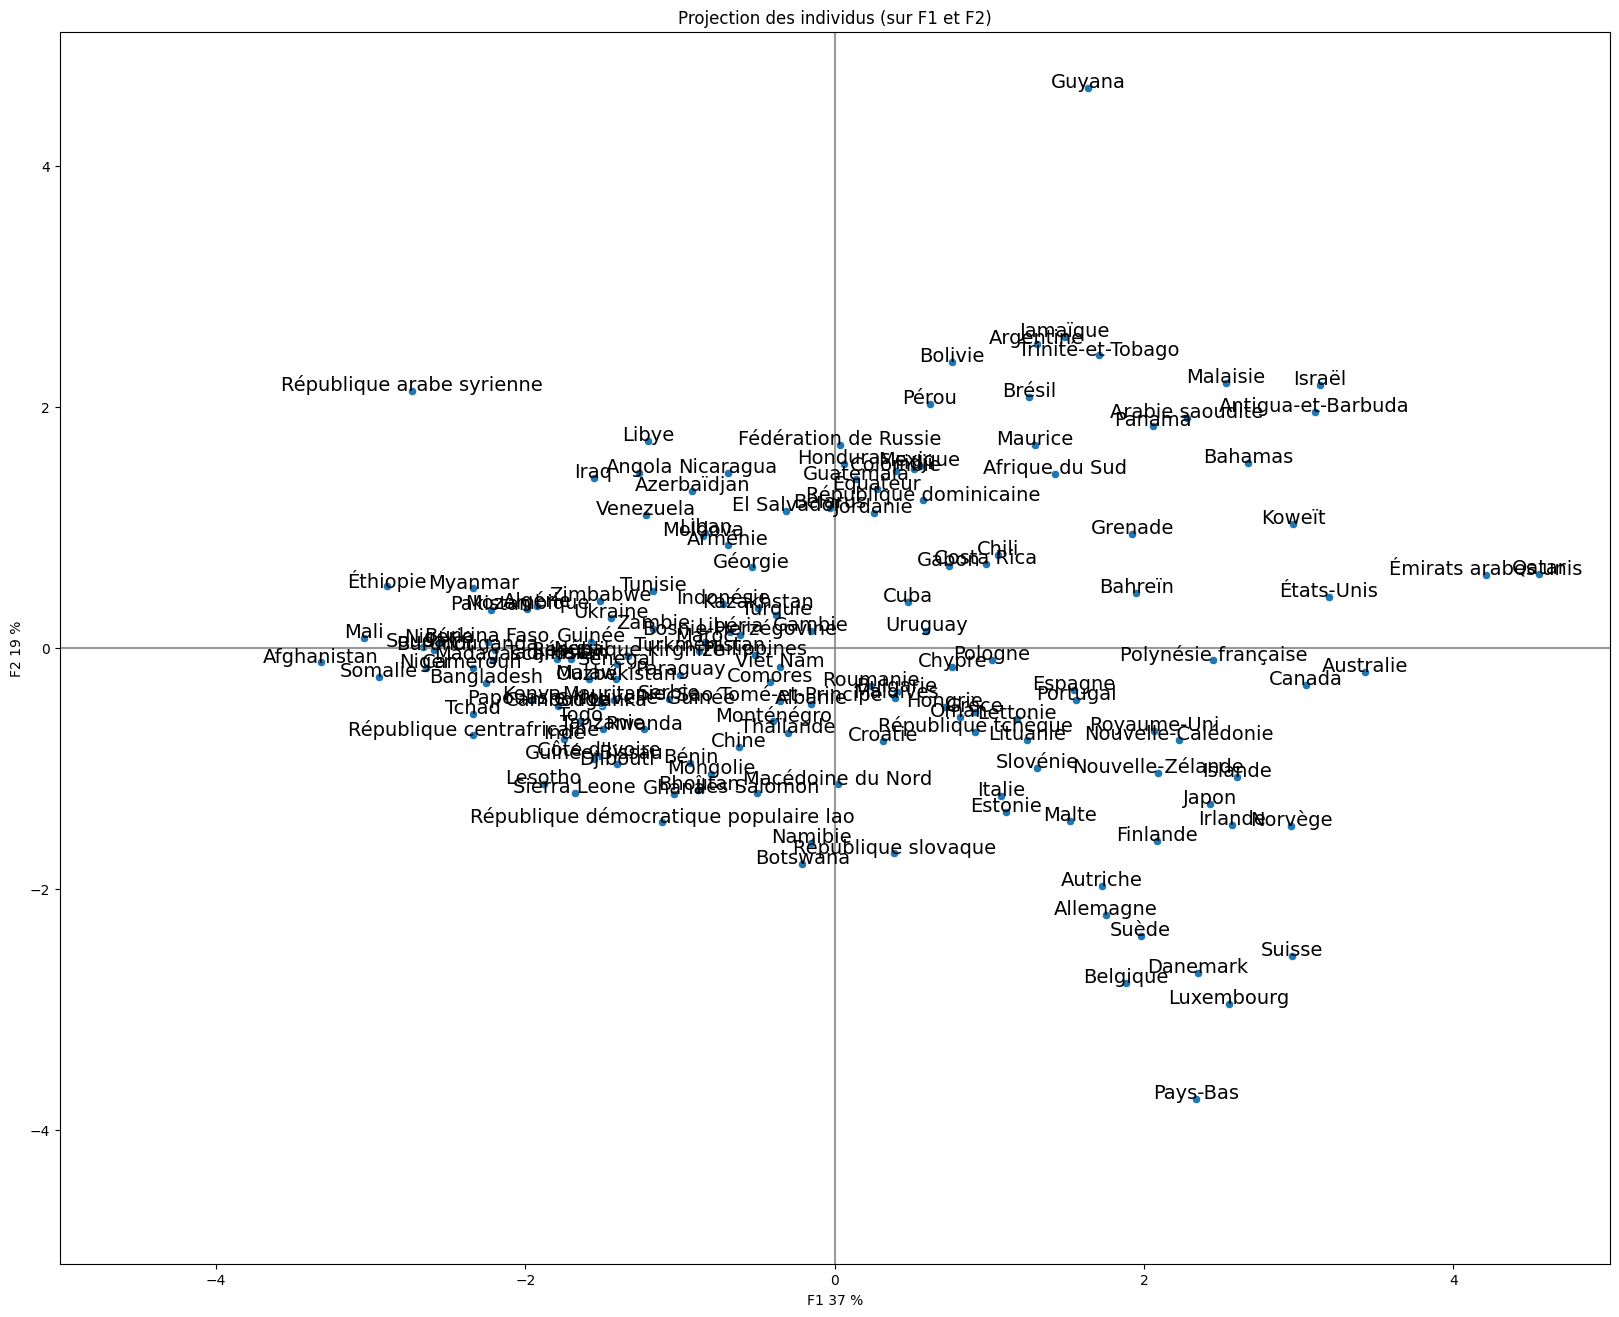

In [489]:
x_y = [0,1]
display_factorial_planes(X_proj, x_y, pca, labels=pays, figsize=(20,16), marker="o")

## Clustering

In [490]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Classification Ascendante Hiérarchique

C'est un algorithme qui permet de constituer ou construire des groupements d'individus (pays) possédant des traits de caractères communs et de manière itérative.  
Il se base sur les "distances" entre chaque paire de points de données.  
Pour commencer, grâce à la librairie scipy, on peut calculer nos distances très simplement. Cette matrice de distance est notée en général Z.  

Nous pouvons ensuite afficher cette arborescence des points et qui se divise petit à petit jusqu'à avoir autant de clusters que de points sous la forme d'un arbre,  
communément appelé dendogramme.

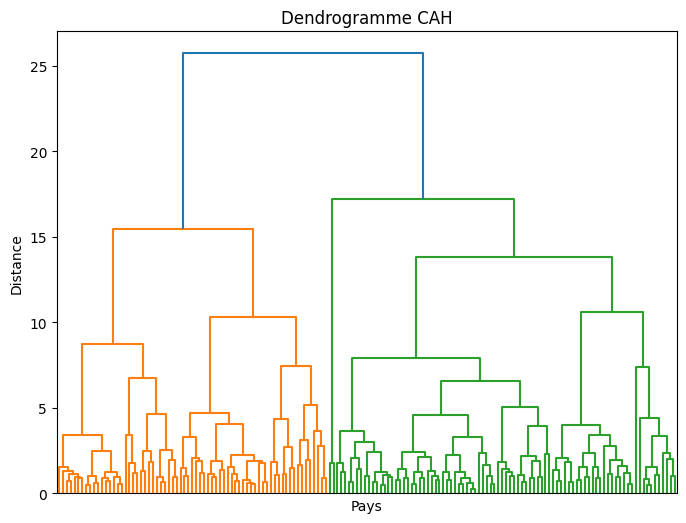

In [491]:
# Calcule la matrice de liaison
Z = linkage(X_scaled, method='ward', metric='euclidean')

# Trace le dendogramme
fig, ax = plt.subplots(figsize=(8, 6))

dn = dendrogram(Z, no_labels=True, orientation='top', ax=ax)

ax.set_title('Dendrogramme CAH')
ax.set_xlabel('Pays')
ax.set_ylabel('Distance')

plt.show()

del  fig, ax, dn

On cherche ensuite la distance (en ordonnée) à laquelle couper le dendrogramme de manière à former les *clusters*. Cependant, le choix de la distance par lecture visuelle est subjective, d'autant plus avec le nombre d'individus présents dans nos données.

Pour choisir un nombre de *clusters* de manière plus objective, nous allons nous appuyer sur le **coefficient de Silhouette** qui rend compte de la qualité d'un regroupement. Il mesure à quel point les individus d'un même groupe sont similaires entre eux par rapport aux objets des autres groupes.

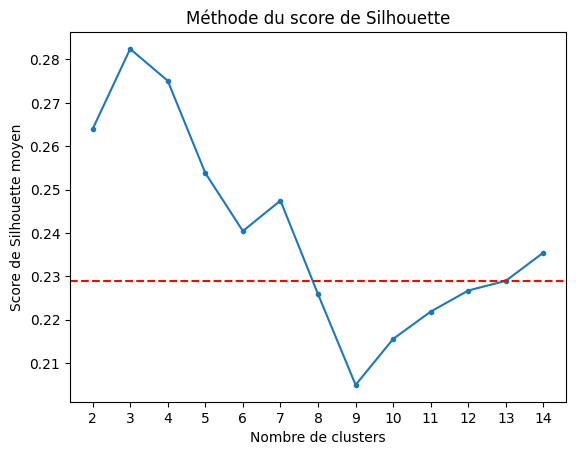

In [492]:
# Initialise les variables
n_clusters_range = range(2, 15)
silhouette_avg_scores = []

# Calcule le score de Silhouette moyen pour chaque valeur du nombre de clusters
for n_clusters in n_clusters_range:
    clustering = fcluster(Z, t=n_clusters, criterion='maxclust')
    silhouette_avg = silhouette_score(X_scaled, clustering)
    silhouette_avg_scores.append(silhouette_avg)

# Trace le graphique
fig, ax = plt.subplots()

plt.plot(n_clusters_range, silhouette_avg_scores, marker='.')
plt.axhline(y=silhouette_avg_scores[11], linestyle = '--', color='r')

# Définit la position des graduations
ax.xaxis.set_major_locator(ticker.IndexLocator(1, 0))

ax.set_xlabel('Nombre de clusters')
ax.set_ylabel('Score de Silhouette moyen')
ax.set_title('Méthode du score de Silhouette')

plt.show()

del (n_clusters_range, silhouette_avg_scores, n_clusters, clustering,
     silhouette_avg, fig, ax)

La méthode du score de Silhouette nous indique que le nombre optimal de *clusters* est 3.  
Nous pourrions également choisir encore 4 à 7 *clusters* voire 13.  
Nous allons tester avec ces différentes valeurs.  
Néanmoins, 3 est trop peu par rapport au nombre de pays à grouper. On choisit donc la meilleure valeur au dessus de la moyenne  
du score de Silhouette qui est de **7**.

In [493]:
n_clusters = 3
clustering = fcluster(Z, t=n_clusters, criterion='maxclust')

# Ajoutez les labels au DataFrame
df_indicateurs['cluster_cah'] = clustering

# Comptez les pays par cluster
print(df_indicateurs['cluster_cah'].value_counts())


cluster_cah
3    87
1    69
2     2
Name: count, dtype: int64


In [494]:
n_clusters = 5
clustering = fcluster(Z, t=n_clusters, criterion='maxclust')

# Ajoutez les labels au DataFrame
df_indicateurs['cluster_cah'] = clustering

# Comptez les pays par cluster
print(df_indicateurs['cluster_cah'].value_counts())


cluster_cah
4    55
2    38
5    32
1    31
3     2
Name: count, dtype: int64


3 ou 5 *clusters* nous paraissent trop peu par rapport au nombre de pays à grouper (158).

In [495]:
n_clusters = 7
clustering = fcluster(Z, t=n_clusters, criterion='maxclust')

# Ajoutez les labels au DataFrame
df_indicateurs['cluster_cah'] = clustering

# Comptez les pays par cluster
print(df_indicateurs['cluster_cah'].value_counts())


cluster_cah
5    55
1    31
2    23
6    21
3    15
7    11
4     2
Name: count, dtype: int64


7 *clusters* nous paraissent bien.  
Nous allons donc attribués les clusters à nos pays et les afficher.

In [496]:
# Crée la liste des clusters triés par ordre croissant
clusters = np.sort(df_indicateurs['cluster_cah'].unique())

# Liste les pays de chaque cluster et les affiche
for cluster in clusters:
    n_pays = len(
        df_indicateurs.loc[df_indicateurs['cluster_cah'] == cluster, 'pays'])
    liste_pays = list(
        df_indicateurs.loc[df_indicateurs['cluster_cah'] == cluster, 'pays'])

    print(f'Cluster {cluster} - {n_pays} pays')
    print(f'{liste_pays}')

del clusters, cluster, n_pays, liste_pays

Cluster 1 - 31 pays
['Autriche', 'Belgique', 'Bulgarie', 'Suisse', 'Chypre', 'République tchèque', 'Allemagne', 'Danemark', 'Espagne', 'Estonie', 'Finlande', 'Royaume-Uni', 'Grèce', 'Croatie', 'Hongrie', 'Irlande', 'Islande', 'Italie', 'Japon', 'Lituanie', 'Luxembourg', 'Lettonie', 'Malte', 'Pays-Bas', 'Norvège', 'Nouvelle-Zélande', 'Pologne', 'Portugal', 'Roumanie', 'Slovénie', 'Suède']
Cluster 2 - 23 pays
['Argentine', 'Bélarus', 'Bolivie', 'Brésil', 'Chili', 'Colombie', 'Costa Rica', 'République dominicaine', 'Équateur', 'Fidji', 'Guatemala', 'Honduras', 'Jamaïque', 'Jordanie', 'Mexique', 'Maurice', 'Malaisie', 'Panama', 'Pérou', 'Fédération de Russie', 'Trinité-et-Tobago', 'Uruguay', 'Afrique du Sud']
Cluster 3 - 15 pays
['Émirats arabes unis', 'Antigua-et-Barbuda', 'Australie', 'Bahreïn', 'Bahamas', 'Canada', 'Gabon', 'Grenade', 'Israël', 'Koweït', 'Nouvelle-Calédonie', 'Polynésie française', 'Qatar', 'Arabie saoudite', 'États-Unis']
Cluster 4 - 2 pays
['Chine', 'Inde']
Cluster 5 

Nous synthétisons également les indicateurs des *clusters* en calculant leur moyenne.

In [497]:
cah_clusters_statistics = (
    df_indicateurs.groupby('cluster_cah')[indicateurs].mean()
)

(cah_clusters_statistics
 .T.style.background_gradient(axis='columns').format('{:.2f}')
)

cluster_cah,1,2,3,4,5,6,7
indice_logistique,3.66,2.76,3.48,3.60,2.35,2.52,2.37
population_milliers_hab,19041.96,36566.29,31379.86,1425301.39,44650.48,5278.22,12226.09
consommation_volaille_pct,2.42,5.39,5.68,1.11,1.35,1.81,1.68
tdi_pct,50.26,10.52,64.53,2.74,15.54,91.48,59.38
disponibilite_kg_p_an,23.89,38.96,51.79,10.32,9.30,13.76,15.19
taux_croissance_pct,0.05,11.64,11.20,4.97,3.82,6.14,40.75
revenu_par_habitant_usd,42782.72,9641.60,41036.43,7429.75,2806.85,6133.20,5638.21
indice_stabilite_politique,0.71,-0.04,0.34,-0.78,-0.94,0.14,-0.69


Ce tableau nous permet de bien visualiser les caractéristiques de chaque groupe.  
Les groupes *3* et *1* ont une majorité d'indicateurs avec des moyennes élevées.  
Nous retiendrons donc ces 2 groupes pour afficher plus de détail.

In [498]:
def clusters_boxplot(clusters, clusters_retenus):
    '''
    Trace la dispersion des indicateurs pour chaque clusters.
    Paramètres :
    - clusters : la série contenant les clusters.
    - clusters_retenus : l'array contenant la liste des clusters à analyser.
    '''
    # Crée un DataFrame tempraire avec les clusters retenus
    df_temp = (
        df_indicateurs.loc[clusters.isin(clusters_retenus)]
    ).copy()

    # Trace le graphique pour chaque indicateur
    fig, axs = plt.subplots(3, 3, figsize=(9.6, 7.68))

    for i, indicateur in enumerate(indicateurs):
        r = i // 3
        c = i % 3
        sns.boxplot(data=df_temp, x=indicateur,
                    y=clusters.name, orient='h',
                    ax=axs[r, c])
        
    # Supprime les graphiques vides
    [fig.delaxes(ax) for ax in axs.flatten() if not ax.has_data()]

    fig.suptitle('Dispersion des indicateurs')

    fig.tight_layout()

    plt.show()

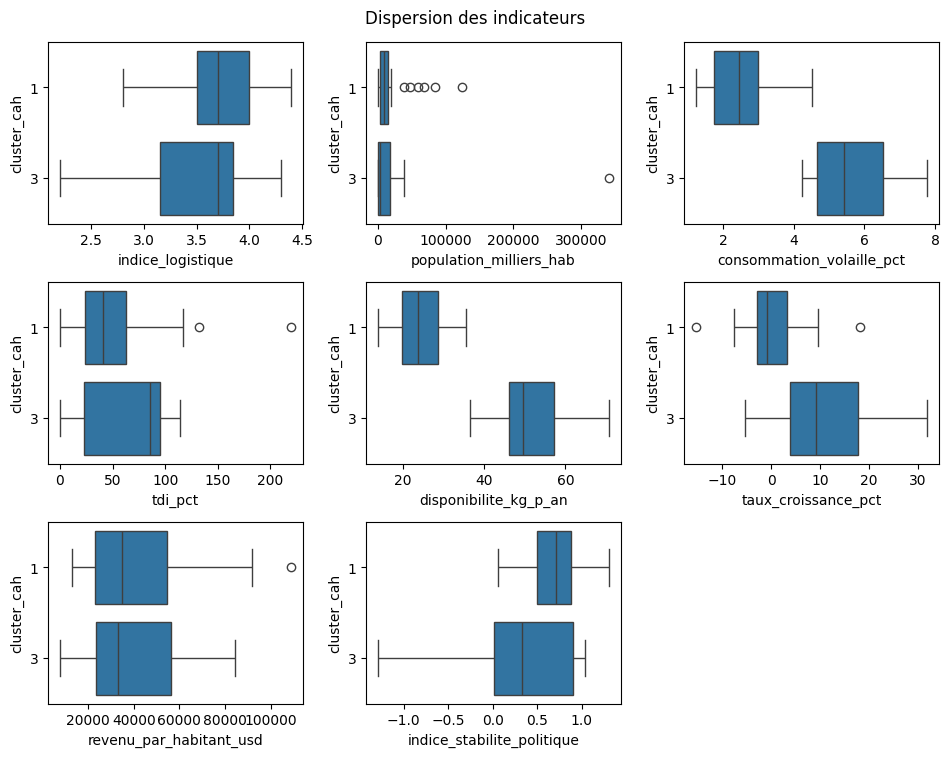

In [499]:
clusters_boxplot(df_indicateurs['cluster_cah'], [3, 1])

In [500]:
clusters_retenus_cah = [3, 1]

pays_retenus_cah = set(
    df_indicateurs.loc[df_indicateurs['cluster_cah'].isin([3, 1]), 'pays']
)

## K-Means

La seconde méthode que nous allons utiliser est la **classification k-means**. Elle va regrouper les individus en cherchant à minimiser l'inertie intraclasse de chaque groupe.  
Pour cela, l'algorithme utilise les centres de gravité (centroïdes) des groupes. Au départ, les centroïdes sont placés aléatoirement puis, ils sont recaculés à chaque itération  
jusqu'à ce que les résultats de l'algorithme convergent.

Pour choisir le nombre optimal de *clusters* nous allons nous appuyer sur la **méthode du coude** dans laquelle nous allons calculer l'inertie intraclasse en fonction du nombre  
de groupes. On cherchera alors à déterminer à partir de quand l'augmentation du nombre de *clusters* n'a plus un impact significatif sur la diminution de l'inertie.

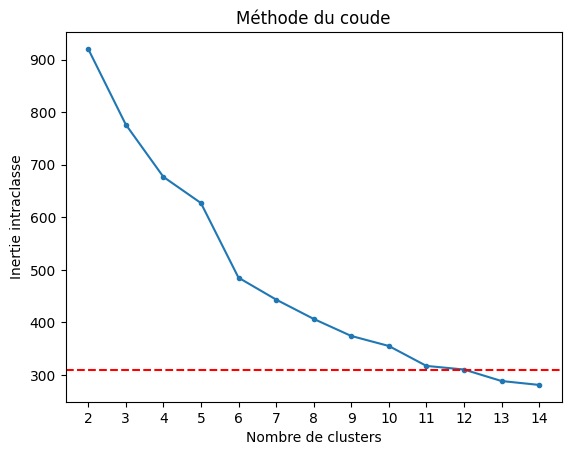

In [501]:
# Initialise les variables
n_clusters_range = range(2, 15)
inertias=[]

# Calcul l'inertie pour chaque valeur du nombre de clusters
for n_clusters in n_clusters_range:
    clustering = KMeans(n_clusters=n_clusters, n_init='auto', init='random',
                      random_state=0)
    clustering = clustering.fit(X_scaled)
    inertias.append(clustering.inertia_)

# Trace le graphique
fig, ax = plt.subplots()

plt.plot(n_clusters_range, inertias, marker='.')
plt.axhline(y=inertias[10], linestyle = '--', color='r')

# Définit la position des graduations
ax.xaxis.set_major_locator(ticker.IndexLocator(1, 0))

ax.set_xlabel('Nombre de clusters')
ax.set_ylabel('Inertie intraclasse')
ax.set_title('Méthode du coude')

plt.show()

del n_clusters_range, inertias, n_clusters, clustering, fig, ax

La cassure se situe entre 6 et 8 *clusters*; elle n'est pas flagrante. Cependant, comme dit précédemment, au vu du nombre de pays à regrouper,  
cela nous semble trop peu. Nous choisirons 8 clusters.  

Pour vérifier cela, nous allons calculer à nouveau un score de Silhouette.

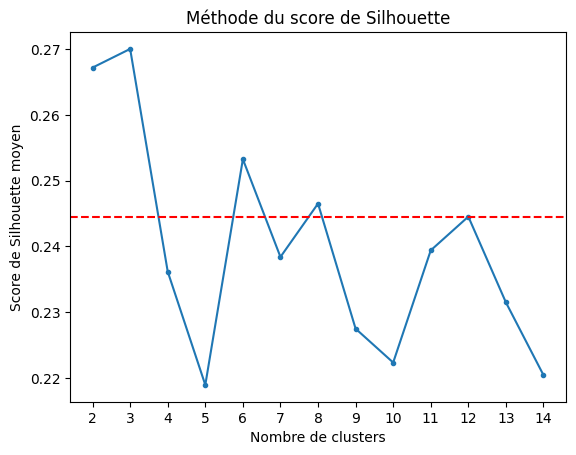

In [502]:
# Initialise les variables
n_clusters_range = range(2, 15)
silhouette_avg_scores = []

# Calcule le score de Silhouette moyen pour chaque nombre de clusters
for n_clusters in n_clusters_range:
    clustering = KMeans(n_clusters=n_clusters, n_init='auto', init='random',
                      random_state=0)
    clustering = clustering.fit(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, clustering.labels_)
    silhouette_avg_scores.append(silhouette_avg)

# Trace le graphique
fig, ax = plt.subplots()

plt.plot(n_clusters_range, silhouette_avg_scores, marker='.')
plt.axhline(y=silhouette_avg_scores[10], linestyle = '--', color='r')

# Définit la position des graduations
ax.xaxis.set_major_locator(ticker.IndexLocator(1, 0))

ax.set_xlabel('Nombre de clusters')
ax.set_ylabel('Score de Silhouette moyen')
ax.set_title('Méthode du score de Silhouette')

plt.show()

del (n_clusters_range, silhouette_avg_scores, n_clusters, clustering,
     silhouette_avg, fig, ax)

6 *clusters* répond au score de Silhouette moyen.  

Nous pouvons donc effectuer le clustering.

In [503]:
# Initialise le nombre de clusters
n_clusters = 8

# Effectue le clustering
clustering = KMeans(n_clusters=n_clusters, n_init='auto', init='random',
                    random_state=0)
clustering.fit(X_scaled)

KMeans(init='random', random_state=0)

Nous enregistrons les labels des *clusters* K-Means dans notre df_indicateurs

In [504]:
df_indicateurs['cluster_kmeans'] = clustering.labels_ + 1

Nous affichons les *clusters* des différents pays selon la méthode K-Means

In [505]:
# Crée la liste des clusters triés par ordre croissant
clusters = np.sort(df_indicateurs['cluster_kmeans'].unique())

# Liste les pays de chaque cluster et les affiche
for cluster in clusters:
    n_pays = len(
        df_indicateurs.loc[df_indicateurs['cluster_kmeans'] == cluster, 'pays'])
    liste_pays = list(
        df_indicateurs.loc[df_indicateurs['cluster_kmeans'] == cluster, 'pays'])

    print(f'Cluster {cluster} - {n_pays} pays')
    print(f'{liste_pays}')

del clusters, cluster, n_pays, liste_pays

Cluster 1 - 46 pays
['Afghanistan', 'Burundi', 'Burkina Faso', 'Bangladesh', 'Bosnie-Herzégovine', 'République centrafricaine', "Côte d'Ivoire", 'Cameroun', 'Algérie', 'Éthiopie', 'Guinée-Bissau', 'Indonésie', 'Kenya', 'Cambodge', 'République démocratique populaire lao', 'Liban', 'Libye', 'Sri Lanka', 'Lesotho', 'Maroc', 'Moldova', 'Madagascar', 'Mali', 'Myanmar', 'Mozambique', 'Malawi', 'Niger', 'Nigéria', 'Népal', 'Pakistan', 'Paraguay', 'Soudan', 'Sénégal', 'Sierra Leone', 'Somalie', 'Serbie', 'Tchad', 'Togo', 'Tadjikistan', 'Tunisie', 'Tanzanie', 'Ouganda', 'Ukraine', 'Ouzbékistan', 'Venezuela', 'Zimbabwe']
Cluster 2 - 23 pays
['Bulgarie', 'Chypre', 'République tchèque', 'Espagne', 'Estonie', 'Grèce', 'Croatie', 'Hongrie', 'Italie', 'Lituanie', 'Lettonie', 'Malte', 'Nouvelle-Calédonie', 'Philippines', 'Pologne', 'Portugal', 'Roumanie', 'République slovaque', 'Slovénie', 'Thaïlande', 'Turquie', 'Uruguay', 'Viet Nam']
Cluster 3 - 13 pays
['Angola', 'Arménie', 'Azerbaïdjan', 'Géorgie'

Enfin, on affiche les centroïdes des indicateurs, qui correspondent à leurs moyennes, grâce à l'attribut `cluster_centers_`. Pour récupérer les valeurs réelles non normalisées, on utilise la méthode `inverse_transform()` de `StandardScaler()`.

In [506]:
# Crée un DataFrame à partir des centroïdes avec les données non normalisées
kmeans_clusters_statistics = pd.DataFrame(
    scaler.inverse_transform(clustering.cluster_centers_)).T

# Définit les indicateurs comme index
kmeans_clusters_statistics = kmeans_clusters_statistics.set_index(indicateurs)

# Renomme les colonnes
kmeans_clusters_statistics.columns = kmeans_clusters_statistics.columns + 1

# Affiche le DataFrame
(kmeans_clusters_statistics
 .style.background_gradient(axis='columns').format('{:.2f}'))

,1,2,3,4,5,6,7,8
indice_logistique,2.26,3.36,2.46,2.43,3.60,2.65,3.41,4.00
population_milliers_hab,43316.74,26457.95,15085.94,5862.12,1425301.39,34032.12,8738.11,42773.01
consommation_volaille_pct,1.14,2.57,1.42,2.00,1.11,5.25,6.40,2.57
tdi_pct,14.02,38.02,67.00,88.62,2.74,9.93,70.64,51.69
disponibilite_kg_p_an,7.77,23.58,10.58,15.12,10.31,39.04,55.56,26.54
taux_croissance_pct,2.27,2.22,34.05,5.50,4.97,14.46,14.95,-0.04
revenu_par_habitant_usd,2285.42,20344.41,5560.21,4920.78,7429.75,9061.42,35373.43,64083.89
indice_stabilite_politique,-1.01,0.37,-0.73,0.08,-0.78,-0.11,0.29,0.83


Cette fois-ci, nous sélectionnons les groupes *8* et *7* qui présentent une majorité de moyennes avec des valeurs élevées.  

Nous affichons plus de détails pour ces 2 groupes dans des boxplots.

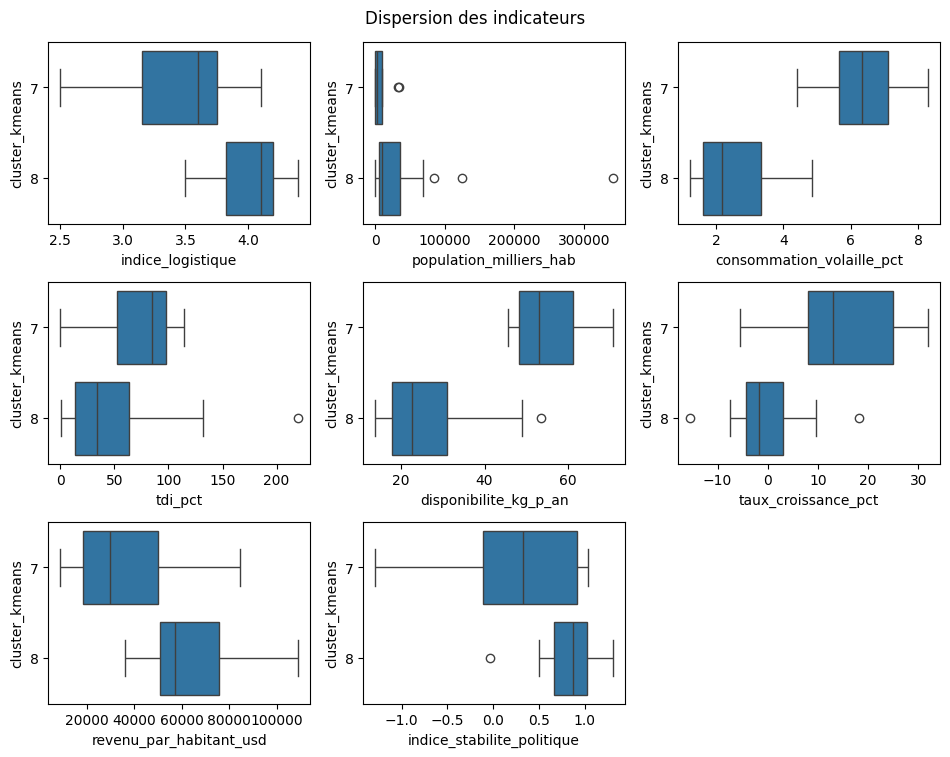

In [507]:
clusters_boxplot(df_indicateurs['cluster_kmeans'], [8, 7])

In [508]:
clusters_retenus_kmeans = [8, 7]

pays_retenus_kmeans = set(
    df_indicateurs.loc[df_indicateurs['cluster_kmeans'].isin([8, 7]), 'pays']
)

## Projection

L'objectif maintenant est de projeté nos individus (pays) selon nos 2 méthodes de regroupement (CAH et K-Means) et en fonction de nos 2 facteurs retenus avec l'ACP.

### CAH vs K-Means

Nous réalisons une fonction qui nous permettra d'afficher les 2 projections.

In [509]:
def acp_clusters_plot(x_d, y_d, clusters, pca=pca, X_pca=X_pca):
    '''
    Trace le graphique des observations d'une ACP avec leur cluster.
    Paramètres :
    - x_d : la dimension de l'ACP a représenter sur l'axe x.
    - y_d : la dimension de l'ACP a représenter sur l'axe y.
    - clusters : la série contenant les clusters.
    - pca : la décomposition effectuée.
    - X_pca : la matrice des individus avec les dimensions calculées
    '''

    # Initialise les variables
    cum_variance_ratio = (pca.explained_variance_ratio_[x_d]
                          + pca.explained_variance_ratio_[y_d])
    df = pd.DataFrame(X_pca)
    df['cluster'] = clusters
    n_clusters = len(df['cluster'].unique())
    markers = ['p', '+', '*', 'x']

    fig, ax = plt.subplots(figsize=(6.4, 6.4))

    # Personnalise le graphique
    ax.set_aspect('equal')
    ax.grid(alpha=0.4)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # Trace les lignes en pointillés pour x = 0  et y = 0
    ax.axhline(y=0, linestyle = '--', linewidth=0.9, color='k')
    ax.axvline(x=0, linestyle = '--', linewidth=0.9, color='k')

    # Affiche la position des individus
    for i in range(1, (n_clusters+1)):
        j = i % len(markers)
        ax.scatter(
            df.loc[df['cluster'] == i, x_d],
            df.loc[df['cluster'] == i, y_d],
            marker=markers[j], label=i
        )
   
    # Ajoute les titre (axes et figure)
    ax.set_xlabel(f'F{x_d + 1} ({pca.explained_variance_ratio_[x_d]:.1%})')
    ax.set_ylabel(f'F{y_d + 1} ({pca.explained_variance_ratio_[y_d]:.1%})')

    ax.set_title(f'Observations "{clusters.name}" sur F{x_d + 1} et F{y_d + 1}'
                 f' ({cum_variance_ratio:.1%})')

    fig.tight_layout()

    plt.legend(title='Cluster :')
 
    plt.show()

Nous appliquons la fonction pour les 2 méthodes de regroupement.

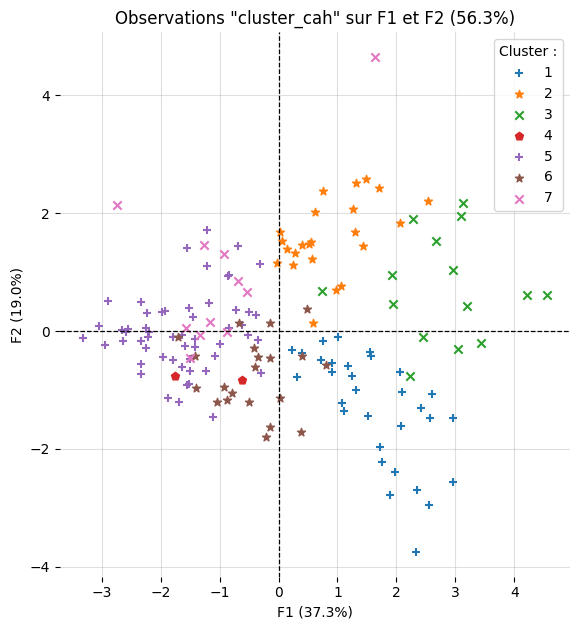

Clusters retenus avec la CAH : [3, 1]



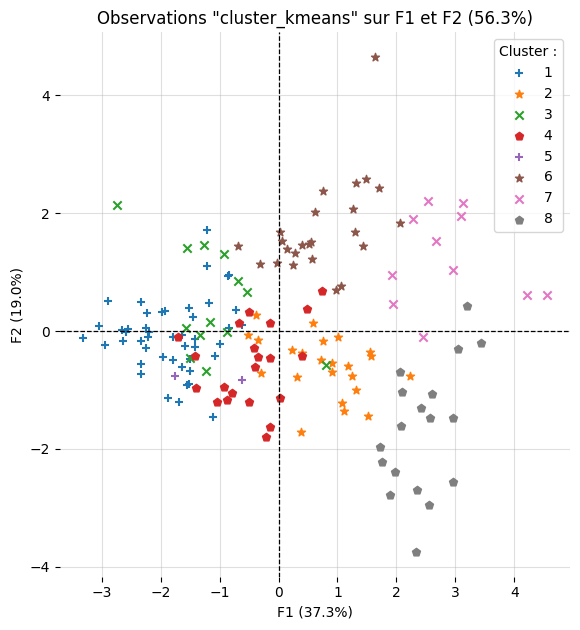

Clusters retenus avec les k-means : [8, 7]


In [510]:
acp_clusters_plot(0, 1, df_indicateurs['cluster_cah'])
print(f'Clusters retenus avec la CAH : {clusters_retenus_cah}\n')

acp_clusters_plot(0, 1, df_indicateurs['cluster_kmeans'])
print(f'Clusters retenus avec les k-means : {clusters_retenus_kmeans}')

En fonction des clusters retenus pour chaque méthode, nous nous apercevons que les individus se situent dans les mêmes zones du plan factoriel.

## Recommandations

### Recommandations générales

A l'aide de nos 2 méthodes de classification, nous pouvons recommander tous les pays retenus.

In [511]:
# Affiche le nombre de pays contenus dans chaque liste
print(f'Nombre de pays :')
print(f'- CAH : {len(pays_retenus_cah)}')
print(f'- k-means : {len(pays_retenus_kmeans)}')

Nombre de pays :
- CAH : 46
- k-means : 29


In [512]:
# Affiche les différences entre les liste
pays_differents = ((pays_retenus_cah-pays_retenus_kmeans)
                   .union(pays_retenus_kmeans-pays_retenus_cah))

print(f'Les pays qui diffèrent sont : {pays_differents}')

Les pays qui diffèrent sont : {'Hongrie', 'Bulgarie', 'Chypre', 'Lituanie', 'Italie', 'Malaisie', 'Lettonie', 'Grèce', 'Espagne', 'Malte', 'Slovénie', 'Roumanie', 'République tchèque', 'Estonie', 'Croatie', 'Pologne', 'Gabon', 'Nouvelle-Calédonie', 'Portugal'}


In [513]:
# Affiche tous les pays retenus
pays_retenus = pays_retenus_cah.union(pays_retenus_kmeans)
print(f'Liste des pays retenus :\n{pays_retenus}')

Liste des pays retenus :
{'Bulgarie', 'Pays-Bas', 'Allemagne', 'Luxembourg', 'Lituanie', 'Polynésie française', 'États-Unis', 'Antigua-et-Barbuda', 'Suisse', 'Bahamas', 'Islande', 'Espagne', 'Autriche', 'République tchèque', 'Grenade', 'Croatie', 'Portugal', 'Danemark', 'Israël', 'Émirats arabes unis', 'Norvège', 'Canada', 'Bahreïn', 'Koweït', 'Nouvelle-Zélande', 'Hongrie', 'Chypre', 'Italie', 'Belgique', 'Suède', 'Malaisie', 'Royaume-Uni', 'Irlande', 'Japon', 'Finlande', 'Grèce', 'Lettonie', 'Arabie saoudite', 'Malte', 'Slovénie', 'Roumanie', 'Estonie', 'Pologne', 'Gabon', 'Nouvelle-Calédonie', 'Australie', 'Qatar'}


### Recommandations spécifiques

Notre entreprise souhaite ouvrir son activité de commerce de volaille biologique à l'international.  
Sur la base des pays retenus, nous pouvons encore recommander spécifiquement certains pays à l'aide d'un score issu de différentes variables.  
Nous avons donc prioriser les revenu_par_habitant_usd, l'indice_logistique et la consommation_volaille_pct.

In [514]:
# Crée un DataFrame avec les pays retenus
df_pays_retenus = (
    df_indicateurs.loc[df_indicateurs['pays'].isin(pays_retenus)]
    .drop(columns={'cluster_cah', 'cluster_kmeans'})
    .reset_index(drop=True)
)

df_pays_retenus['score'] = (
    df_pays_retenus['revenu_par_habitant_usd'] * 0.4 +
    df_pays_retenus['indice_logistique'] * 0.3 +
    df_pays_retenus['consommation_volaille_pct'] * 0.3
)

df_pays_retenus.nlargest(15, 'score')

,pays,indice_logistique,population_milliers_hab,consommation_volaille_pct,tdi_pct,disponibilite_kg_p_an,taux_croissance_pct,revenu_par_habitant_usd,indice_stabilite_politique,score
36,Norvège,3.9,5456.801,2.04,3.36,21.51,18.178725,109081.979894,0.86,43634.573958
9,Suisse,4.4,8792.182,1.64,31.01,18.01,0.616880,91745.049488,1.16,36699.831795
30,Luxembourg,3.6,653.313,1.50,116.67,19.84,-4.735933,84804.336933,1.06,33923.264773
41,Qatar,3.8,2892.455,5.85,85.14,59.16,31.919245,84568.338448,0.96,33830.230379
46,États-Unis,3.9,341534.045,4.85,1.05,53.54,9.112910,77086.551228,-0.04,30837.245491
23,Irlande,3.5,5110.016,2.53,63.22,31.18,3.705548,76118.080848,0.88,30449.041339
24,Islande,3.6,380.356,2.44,16.67,30.74,9.644457,74914.531669,1.26,29967.624668
13,Danemark,4.1,5902.904,1.47,93.40,17.83,-1.360850,70377.331271,0.87,28152.603508
2,Australie,4.1,26200.984,4.48,0.30,49.09,1.362986,65058.904861,0.93,26026.135944
45,Suède,4.2,10487.338,1.62,43.95,16.35,-7.585623,58014.983404,0.90,23207.739362


In [515]:
pays_retenus = pd.DataFrame(pays_retenus)
print(pays_retenus[0:18])


                      0
0              Bulgarie
1              Pays-Bas
2             Allemagne
3            Luxembourg
4              Lituanie
5   Polynésie française
6            États-Unis
7    Antigua-et-Barbuda
8                Suisse
9               Bahamas
10              Islande
11              Espagne
12             Autriche
13   République tchèque
14              Grenade
15              Croatie
16             Portugal
17             Danemark


In [516]:
print(pays_retenus[18:36])

                      0
18               Israël
19  Émirats arabes unis
20              Norvège
21               Canada
22              Bahreïn
23               Koweït
24     Nouvelle-Zélande
25              Hongrie
26               Chypre
27               Italie
28             Belgique
29                Suède
30             Malaisie
31          Royaume-Uni
32              Irlande
33                Japon
34             Finlande
35                Grèce


In [517]:
print(pays_retenus[36:55])

                     0
36            Lettonie
37     Arabie saoudite
38               Malte
39            Slovénie
40            Roumanie
41             Estonie
42             Pologne
43               Gabon
44  Nouvelle-Calédonie
45           Australie
46               Qatar


In [518]:
print(pays_retenus[55:75])

Empty DataFrame
Columns: [0]
Index: []
